### **Part 1 – Problem Definition & Data Collection**

#### **1.1 Problem Definition**

The purpose of this project is to develop a machine learning regression model that predicts the inhibitory potency of small molecules against the EGFR kinase using experimentally measured IC50 values from the ChEMBL bioactivity database. The IC50 values are standardized and transformed into pIC50 (–log10 of IC50 in molar units), which serves as the continuous regression target.

#### **Why is this important?**
Kinase inhibitors constitute one of the most important drug classes in oncology. Experimental biochemical assays for IC50 measurements are costly, time-consuming, and limited by screening capacity. Accurate computational models can significantly accelerate drug discovery by prioritizing potent candidates before laboratory evaluation.

#### **Dataset Characteristics**
- **Source:** ChEMBL bioactivity database  
- **Target:** EGFR (CHEMBL203), a well-characterized human kinase  
- **Input representation:** Canonical SMILES strings describing molecular structures, further standardized using RDKit (normalization and canonicalization) to obtain a consistent std_smiles representation for modeling
- **Target variable:** pIC50 derived from high-quality IC50 measurements (nM → pIC50) 
- **Assay type:** Only **binding assays** (*assay_type = “B”*) are included to avoid mixing biochemical and functional readouts
- **Activity filtering:** Only exact IC50 measurements (relation = “=”) reported in nM units are retained  
- **Quality control:** Only records with **confidence_score ≥ 8** are retained, ensuring reliable target assignment
- **Dataset curation:** When multiple measurements exist for the same standardized molecule, the median pIC50 value is used as a robust representative
- **Final dataset:** High-confidence, single-target, single-assay-type, unit-standardized IC50 data

To ensure computational efficiency while preserving chemical diversity, a representative subset of 5,000 molecules was selected using the Kennard–Stone algorithm prior to descriptor calculation and model training.

#### **Objective**
To train and evaluate regression models capable of predicting the binding potency of compounds toward EGFR based solely on molecular structure.

#### **Modeling Task**
- **Type:** Single-target molecular regression  
- **Target:** pIC50  
- **Features:** Molecular descriptors (Lipinski-type physicochemical properties) and Morgan fingerprints (ECFP4) derived from standardized SMILES  
- **Evaluation metrics:** RMSE, MAE, R²  
- **Data split:** Scaffold-based Train / Validation / Test split to ensure robust generalization and avoid scaffold memorization



#### **1.2 Data Collection**

The dataset was retrieved from the ChEMBL bioactivity database using the `chembl_webresource_client` Python API.  

##### **Importing libraries**

In [3]:
# Data handling
import pandas as pd       # dataframes, data processing
import numpy as np        # mathematical operations

# Chemistry / cheminformatics
from rdkit import Chem    # SMILES → molecule object
from rdkit.Chem import Descriptors, AllChem, DataStructs  # molecular descriptors, fingerprints
from rdkit.Chem import PandasTools  # pandas integration for molecules

# Machine Learning
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
!pip install chembl_webresource_client

#### **Retrieving and Filtering High-Quality EGFR IC50 Bioactivity Data (Binding Assays, nM, Confidence ≥ 8)**

In [5]:
from chembl_webresource_client.new_client import new_client

activity = new_client.activity
assay = new_client.assay

# 1) Filtered Bioactivity Retrieval (IC50, nM, '=', Binding Assays)
df_raw = pd.DataFrame.from_dict(
    activity.filter(
        target_chembl_id="CHEMBL203",
        standard_type="IC50",
        standard_units="nM",
        relation="=",
        assay_type="B"
    ).only([
        "activity_id",
        "assay_chembl_id",
        "molecule_chembl_id",
        "canonical_smiles",
        "standard_value",
        "standard_units",
        "standard_type",
        "relation",
        "assay_type",
        "target_chembl_id",
        "pchembl_value"
    ])
)

C:\Users\nezih\anaconda3\envs\bio-chem\lib\site-packages\chembl_webresource_client\__init__.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __version__ = __import__('pkg_resources').get_distribution('chembl_webresource_client').version


In [6]:
df_raw.head()

,activity_id,assay_chembl_id,assay_type,canonical_smiles,molecule_chembl_id,pchembl_value,relation,standard_type,standard_units,standard_value,target_chembl_id,type,units,value
0,32260,CHEMBL674637,B,Cc1cc(C)c(/C=C2\C(=O)Nc3ncnc(Nc4ccc(F)c(Cl)c4)...,CHEMBL68920,7.39,=,IC50,nM,41.0,CHEMBL203,IC50,uM,0.041
1,32267,CHEMBL674637,B,Cc1cc(C(=O)N2CCOCC2)[nH]c1/C=C1\C(=O)Nc2ncnc(N...,CHEMBL69960,6.77,=,IC50,nM,170.0,CHEMBL203,IC50,uM,0.17
2,32680,CHEMBL677833,B,CN(c1ccccc1)c1ncnc2ccc(N/N=N/Cc3ccccn3)cc12,CHEMBL137635,5.03,=,IC50,nM,9300.0,CHEMBL203,IC50,uM,9.3
3,32770,CHEMBL674643,B,CC(=C(C#N)C#N)c1ccc(NC(=O)CCC(=O)O)cc1,CHEMBL306988,None,=,IC50,nM,500000.0,CHEMBL203,IC50,uM,500.0
4,32772,CHEMBL674643,B,O=C(O)/C=C/c1ccc(O)cc1,CHEMBL66879,None,=,IC50,nM,3000000.0,CHEMBL203,IC50,uM,3000.0


In [7]:
# 2) High-Confidence Assay Filtering (confidence_score ≥ 8)
assay_ids = df_raw["assay_chembl_id"].dropna().unique().tolist()

assay_df = pd.DataFrame.from_dict(
    assay.filter(assay_chembl_id__in=assay_ids).only([
        "assay_chembl_id",
        "confidence_score"
    ])
)

merged = df_raw.merge(assay_df, on="assay_chembl_id", how="left")
merged = merged[merged["confidence_score"] >= 8].copy()

# 3) pIC50 computation
merged["standard_value"] = pd.to_numeric(merged["standard_value"], errors="coerce")
merged = merged.dropna(subset=["standard_value"])
merged = merged[merged["standard_value"] > 0]
merged["pIC50"] = -np.log10(merged["standard_value"] * 1e-9)

# 4) Final QSAR-ready DataFrame
df_full = merged[[
    "molecule_chembl_id",
    "canonical_smiles",
    "standard_value",
    "standard_units",
    "pIC50",
    "assay_chembl_id",
    "confidence_score",
    "target_chembl_id"
]]


#### **Final Dataset Overview**

It should be noted that ChEMBL bioactivity data originate from multiple experimental assays, laboratories, and conditions. As a result, assay-to-assay variability and experimental noise are inherent limitations of the dataset. This variability motivates the use of robust preprocessing steps and aggregation strategies and is an important consideration when interpreting model performance.

In this step, only binding (assay_type = "B") IC50 measurements (standard_type = "IC50", standard_units = "nM", relation = "=") were retrieved from ChEMBL for EGFR (CHEMBL203). The corresponding assay records were used to obtain confidence_score values, and only high-confidence measurements with confidence_score ≥ 8 were retained. IC50 values were converted to numeric type, and missing or invalid (NaN) entries, as well as physically meaningless records with standard_value ≤ 0, were removed. Finally, IC50 (nM) values were converted into molar units and pIC50 was computed as pIC50 = –log10(IC50 [M].

After applying the filtering and standardization steps described above, the final dataset consists of 17,651 compounds with experimentally measured IC50 values converted to pIC50, providing a robust and chemically meaningful foundation for subsequent QSAR modeling.


In [8]:
df_full.head()

,molecule_chembl_id,canonical_smiles,standard_value,standard_units,pIC50,assay_chembl_id,confidence_score,target_chembl_id
0,CHEMBL68920,Cc1cc(C)c(/C=C2\C(=O)Nc3ncnc(Nc4ccc(F)c(Cl)c4)...,41.0,nM,7.387216,CHEMBL674637,8,CHEMBL203
1,CHEMBL69960,Cc1cc(C(=O)N2CCOCC2)[nH]c1/C=C1\C(=O)Nc2ncnc(N...,170.0,nM,6.769551,CHEMBL674637,8,CHEMBL203
2,CHEMBL137635,CN(c1ccccc1)c1ncnc2ccc(N/N=N/Cc3ccccn3)cc12,9300.0,nM,5.031517,CHEMBL677833,8,CHEMBL203
3,CHEMBL306988,CC(=C(C#N)C#N)c1ccc(NC(=O)CCC(=O)O)cc1,500000.0,nM,3.301030,CHEMBL674643,8,CHEMBL203
4,CHEMBL66879,O=C(O)/C=C/c1ccc(O)cc1,3000000.0,nM,2.522879,CHEMBL674643,8,CHEMBL203


### **Part 2 – Exploratory Data Analysis (EDA)**

#### **2.1 Dataset Overview**

In [9]:
# Check basic dataset info
print("Shape:", df_full.shape)
print("Columns:", df_full.columns)

Shape: (17651, 8)
Columns: Index(['molecule_chembl_id', 'canonical_smiles', 'standard_value',
       'standard_units', 'pIC50', 'assay_chembl_id', 'confidence_score',
       'target_chembl_id'],
      dtype='object')


In [10]:
# Check datatypes
print(df_full.dtypes)

molecule_chembl_id     object
canonical_smiles       object
standard_value        float64
standard_units         object
pIC50                 float64
assay_chembl_id        object
confidence_score        int64
target_chembl_id       object
dtype: object


In [11]:
# Check for missing values
print(df_full.isnull().sum())

molecule_chembl_id     0
canonical_smiles      17
standard_value         0
standard_units         0
pIC50                  0
assay_chembl_id        0
confidence_score       0
target_chembl_id       0
dtype: int64


In [12]:
# Remove entries with missing SMILES (required for descriptor generation)
df_full = df_full.dropna(subset=["canonical_smiles"]).copy()

print("New shape after removing missing SMILES:", df_full.shape)

New shape after removing missing SMILES: (17634, 8)


#### **2.2 Diversity-Based Subset Selection Using Morgan Fingerprints, PCA, and Kennard–Stone Algorithm**

#### Chemical Diversity–Based Subsampling Using the Kennard–Stone Algorithm

In the original dataset (n = 17,634), many compounds share highly similar chemical structures or scaffolds, leading to redundancy in the chemical space. Using the full dataset substantially increases the computational cost of molecular standardization, descriptor generation, and model training, while offering diminishing returns in terms of structural diversity.

To address this, a representative subset of **5,000 molecules** was selected to maximally cover the chemical space of the full EGFR bioactivity dataset. This ensures that the QSAR model is trained on a **balanced, diverse, and non-redundant** set of compounds that captures the essential structure–activity relationships.

The **Kennard–Stone algorithm** was chosen for subsampling because:

- It systematically selects samples that are maximally distant from one another in feature space.
- It produces subsets that uniformly cover the chemical space, reducing clustering and sampling bias.
- It is widely used in chemometrics for dataset curation, sample representativeness, and robust model development.
- Unlike random sampling, it prevents over-representation of common scaffolds.
- It is computationally efficient when applied to PCA-reduced Morgan fingerprints (ECFP4).

By reducing the dataset from ~17k to 5k using a chemically diverse and statistically principled selection method, subsequent QSAR modeling becomes **faster**, **more interpretable**, and **more robust**—while still preserving the underlying chemical diversity necessary for accurate predictive modeling.


In [13]:
pip install kennard-stone

Note: you may need to restart the kernel to use updated packages.


In [14]:
from sklearn.decomposition import PCA
from kennard_stone import train_test_split

df_full = df_full.copy()

# 1) SMILES → Morgan fingerprint (ECFP4)
from rdkit.Chem import rdFingerprintGenerator
morgan_gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)

fps = []
valid_idx = []

for i, smi in enumerate(df_full["canonical_smiles"]): 
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        continue
    fp = morgan_gen.GetFingerprint(mol)  # uses MorganGenerator internally
    arr = np.zeros((2048,), dtype=int)
    DataStructs.ConvertToNumpyArray(fp, arr)
    fps.append(arr)
    valid_idx.append(i)

X = np.array(fps, dtype=float)
print("Fingerprint matrix shape:", X.shape)

# 2) PCA
pca = PCA(n_components=10, random_state=0)
X_pca = pca.fit_transform(X)
print("PCA-transformed shape:", X_pca.shape)

# 3) Kennard–Stone sampling: use original dataframe indices as y
y_idx = np.array(valid_idx)

X_train, X_rest, idx_train, idx_rest = train_test_split(
    X_pca,
    y_idx,
    train_size=5000,   # select 5000 samples with Kennard–Stone
    test_size=None
)

selected_global_idx = idx_train  # these are directly df_full indices

df_ks_diverse = df_full.iloc[selected_global_idx].reset_index(drop=True)
print(df_ks_diverse.shape)

Fingerprint matrix shape: (17634, 2048)


2025-12-16 10:59:09,455 - kennard_stone.utils._pairwise:114[INFO] - Calculating pairwise distances using scikit-learn.



PCA-transformed shape: (17634, 10)


2025-12-16 10:59:15,532 - kennard_stone.utils._pairwise:114[INFO] - Calculating pairwise distances using scikit-learn.



(5000, 8)


In [15]:
# 4) From here on, use df as the main dataset
df = df_ks_diverse.copy()

In [16]:
df.head()

,molecule_chembl_id,canonical_smiles,standard_value,standard_units,pIC50,assay_chembl_id,confidence_score,target_chembl_id
0,CHEMBL5771679,CC(C)(C)CNc1ncnc2c(Cl)cc(NC(c3ccc(F)cc3)c3cn(C...,10.0,nM,8.000000,CHEMBL5731071,9,CHEMBL203
1,CHEMBL246491,COC(=O)COCc1ccn2ncnc(Nc3ccc4c(cnn4Cc4cccc(F)c4...,460.0,nM,6.337242,CHEMBL903494,8,CHEMBL203
2,CHEMBL3087200,C=CC(=O)N1CC[C@H](N2C(=O)N(C3CCCCC3)Cc3cnc(Nc4...,42.9,nM,7.367543,CHEMBL3088813,9,CHEMBL203
3,CHEMBL5857449,Cn1cnc([C@H](Nc2cc(Cl)c3ncc(C#N)c(Nc4ccc(F)c(C...,37.0,nM,7.431798,CHEMBL5736995,9,CHEMBL203
4,CHEMBL137788,C/N=N/Nc1ccc2ncnc(NCc3ccccc3)c2c1,335.0,nM,6.474955,CHEMBL677833,8,CHEMBL203


#### **2.3 Numerical Summary of IC50 and pIC50 for Full Dataset vs. Diverse Subset**

In [17]:
summary_full = df_full[["standard_value", "pIC50"]].describe()
summary_subset = df[["standard_value", "pIC50"]].describe()

# Rename columns to avoid confusion
summary_full = summary_full.add_prefix("Full_")
summary_subset = summary_subset.add_prefix("Subset_")

# Concatenate side-by-side
summary_combined = pd.concat([summary_full, summary_subset], axis=1)

summary_combined


,Full_standard_value,Full_pIC50,Subset_standard_value,Subset_pIC50
count,1.763400e+04,17634.000000,5.000000e+03,5000.000000
mean,2.653119e+04,7.060929,2.551859e+04,6.823664
std,8.316620e+05,1.390854,8.335294e+05,1.387242
min,5.012000e-09,1.080922,5.012000e-09,1.259637
25%,8.000000e+00,6.097005,1.400000e+01,5.795880
50%,6.600000e+01,7.180456,1.300000e+02,6.886057
75%,7.998250e+02,8.096910,1.600000e+03,7.853872
max,8.300000e+07,17.299989,5.500000e+07,17.299989


#### Interpretation of Numerical Comparison: Full Dataset vs. Diverse 5000-Subset

The diverse 5000-molecule subset selected using Morgan fingerprints, PCA projection, and
Kennard–Stone sampling successfully preserves the statistical characteristics of the full
bioactivity dataset (n = 17,634). The mean, median, standard deviation, and activity range
(min–max) of both IC50 and pIC50 values remain closely aligned between the two datasets.
Notably, the standard deviation (Full: 1.3909 vs. Subset: 1.3872) and the full pIC50 range 
(1.08 to 17.29) are almost perfectly preserved, indicating that the sampling procedure maintains
the chemical and biological diversity of the original dataset.

This confirms that the 5000-compound subset is a representative and unbiased reduction of the
full dataset, suitable for downstream QSAR modeling without losing essential variability or
distorting the underlying activity distribution.


#### **2.4 Comparison of pIC50 Distributions (Full vs. Diverse Subset)**

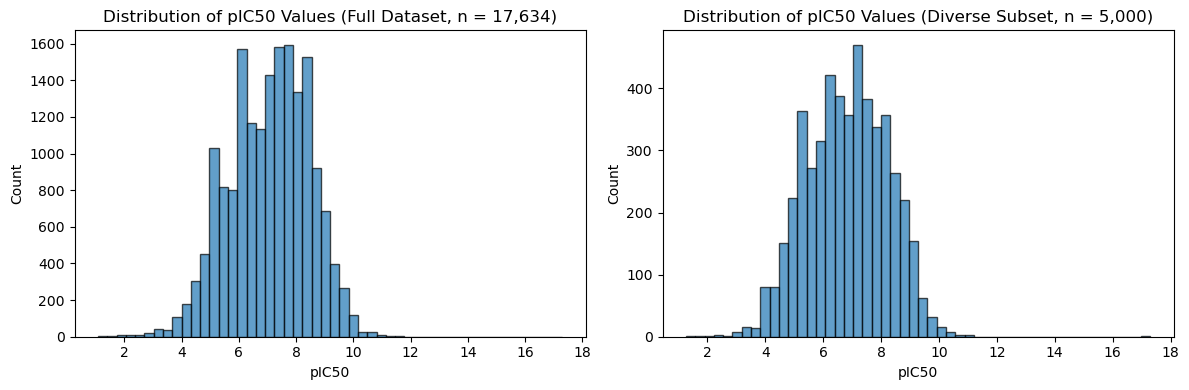

In [18]:
import matplotlib.pyplot as plt

# df_full : full dataset (e.g., n ≈ 17,634)
# df      : diverse subset selected by Kennard–Stone (e.g., n = 5,000)

plt.figure(figsize=(12, 4))  

# 1. subplot: Full dataset
plt.subplot(1, 2, 1)
plt.hist(df_full["pIC50"], bins=50, edgecolor="black", alpha=0.7)
plt.xlabel("pIC50")
plt.ylabel("Count")
plt.title("Distribution of pIC50 Values (Full Dataset, n = 17,634)")

# 2. subplot: Diverse subset
plt.subplot(1, 2, 2)
plt.hist(df_ks_diverse["pIC50"], bins=50, edgecolor="black", alpha=0.7)
plt.xlabel("pIC50")
plt.ylabel("Count")
plt.title("Distribution of pIC50 Values (Diverse Subset, n = 5,000)")

plt.tight_layout()
plt.show()


#### Interpretation of Histogram Comparison (Full Dataset vs. Diverse Subset)

The histogram plots illustrate that the diverse 5,000-compound subset captures the essential
shape and structural characteristics of the full pIC50 distribution without introducing
noticeable distortions. Both datasets display a similar density peak around moderately active
compounds and exhibit gradual tapering toward weak and highly potent regions, indicating that
key activity trends are preserved.

Importantly, the subset reproduces the full dataset’s overall distribution contour—even with
reduced sample size—suggesting that the selection process retained representatives across the
entire biological activity spectrum. The matched distribution shapes confirm that the subset
maintains the diversity of response profiles required for building reliable and generalizable
QSAR models, while significantly reducing computational load.


#### **2.5 Molecular Structure Standardization Using RDKit (Salt Removal, Charge Neutralization, Tautomer and Stereochemistry Normalization**

In [19]:

from rdkit import Chem
from rdkit.Chem.MolStandardize import rdMolStandardize 

# 1) Full SMILES standardization

def standardization_fx(mol_list):
    uncharger = rdMolStandardize.Uncharger()
    standardized = []

    for mol in mol_list:
        if mol is None:
            standardized.append(None)
            continue

        try:
            # 1) remove salts / keep largest fragment
            newmol = rdMolStandardize.FragmentParent(mol)

            # 2) neutralize charges
            newmol = uncharger.uncharge(newmol)

            # 3) canonical tautomer
            newmol = rdMolStandardize.CanonicalTautomer(newmol)

            # 4) normalize functional groups
            newmol = rdMolStandardize.Normalize(newmol)

            # 5) remove stereochemistry if needed
            newmol = rdMolStandardize.StereoParent(newmol)

            standardized.append(newmol)
        except Exception:
            standardized.append(None)

    return standardized

# SMILES -> Mol
mols = [Chem.MolFromSmiles(s) for s in df["canonical_smiles"]]

# Apply standardization
std_mols = standardization_fx(mols)

# Back to canonical SMILES
std_smiles = [
    Chem.MolToSmiles(m, canonical=True) if m is not None else None
    for m in std_mols
]

# Attach to dataframe and drop failures
df["std_smiles"] = std_smiles
df = df.dropna(subset=["std_smiles"]).copy()

print("Rows after standardization:", df.shape[0])


[11:00:09] Initializing MetalDisconnector
[11:00:09] Running MetalDisconnector
[11:00:09] Initializing Normalizer
[11:00:09] Running Normalizer
[11:00:09] Running LargestFragmentChooser
[11:00:09] Running Uncharger
[11:00:09] Initializing Normalizer
[11:00:09] Running Normalizer
[11:00:09] Initializing MetalDisconnector
[11:00:09] Running MetalDisconnector
[11:00:09] Initializing Normalizer
[11:00:09] Running Normalizer
[11:00:09] Initializing MetalDisconnector
[11:00:09] Running MetalDisconnector
[11:00:09] Initializing Normalizer
[11:00:09] Running Normalizer
[11:00:09] Running LargestFragmentChooser
[11:00:09] Running Uncharger
[11:00:09] Initializing Normalizer
[11:00:09] Running Normalizer
[11:00:09] Initializing MetalDisconnector
[11:00:09] Running MetalDisconnector
[11:00:09] Initializing Normalizer
[11:00:09] Running Normalizer
[11:00:09] Initializing MetalDisconnector
[11:00:09] Running MetalDisconnector
[11:00:09] Initializing Normalizer
[11:00:09] Running Normalizer
[11:00:0

Rows after standardization: 5000


In [20]:
df.head()

,molecule_chembl_id,canonical_smiles,standard_value,standard_units,pIC50,assay_chembl_id,confidence_score,target_chembl_id,std_smiles
0,CHEMBL5771679,CC(C)(C)CNc1ncnc2c(Cl)cc(NC(c3ccc(F)cc3)c3cn(C...,10.0,nM,8.000000,CHEMBL5731071,9,CHEMBL203,CC(C)(C)CNc1ncnc2c(Cl)cc(NC(c3ccc(F)cc3)c3cn(C...
1,CHEMBL246491,COC(=O)COCc1ccn2ncnc(Nc3ccc4c(cnn4Cc4cccc(F)c4...,460.0,nM,6.337242,CHEMBL903494,8,CHEMBL203,COC(=O)COCc1ccn2ncnc(Nc3ccc4c(cnn4Cc4cccc(F)c4...
2,CHEMBL3087200,C=CC(=O)N1CC[C@H](N2C(=O)N(C3CCCCC3)Cc3cnc(Nc4...,42.9,nM,7.367543,CHEMBL3088813,9,CHEMBL203,C=CC(=O)N1CCC(N2C(=O)N(C3CCCCC3)Cc3cnc(Nc4ccc(...
3,CHEMBL5857449,Cn1cnc([C@H](Nc2cc(Cl)c3ncc(C#N)c(Nc4ccc(F)c(C...,37.0,nM,7.431798,CHEMBL5736995,9,CHEMBL203,Cn1cnc(C(Nc2cc(Cl)c3ncc(C#N)c(Nc4ccc(F)c(Cl)c4...
4,CHEMBL137788,C/N=N/Nc1ccc2ncnc(NCc3ccccc3)c2c1,335.0,nM,6.474955,CHEMBL677833,8,CHEMBL203,CN=NNc1ccc2ncnc(NCc3ccccc3)c2c1


#### **2.6 Duplicate Resolution Based on Standardized SMILES Using Median pIC50**

When multiple IC50 measurements were available for the same standardized molecule, duplicate entries were resolved by aggregating pIC50 values using the median.

The median was preferred over the mean because it is more robust to outliers arising from assay variability, ensuring that a single extreme measurement does not disproportionately influence the final target value.

In [21]:
# Duplicate check on standardized SMILES
print("Unique std_smiles:", df["std_smiles"].nunique())
print("Total rows:", len(df))
print("Duplicate std_smiles:", df["std_smiles"].notna().sum() - df["std_smiles"].nunique())

Unique std_smiles: 4999
Total rows: 5000
Duplicate std_smiles: 1


In [22]:
# 1) Keep only rows with a valid standardized SMILES
df_non_null = df.dropna(subset=["std_smiles"]).copy()

# 2) Aggregate duplicates: one row per std_smiles using the median pIC50
df_unique = (
    df_non_null
    .groupby("std_smiles", as_index=False)
    .agg({
        # QSAR target
        "pIC50": "median",

        # Resimde gördüğün kolonlar
        "molecule_chembl_id": "first",
        "canonical_smiles": "first",
        "standard_value": "median",
        "standard_units": "first",
        "assay_chembl_id": lambda x: ",".join(sorted(set(x.astype(str)))),  # tüm assay'ler
        "confidence_score": "max",
        "target_chembl_id": "first",
    })
)

# 3) Summary after duplicate resolution
print("Duplicate resolution completed.")
print(f"Final number of unique molecules: {len(df_unique)}")
print("Each standardized SMILES now appears only once (one molecule = one pIC50).")


Duplicate resolution completed.
Final number of unique molecules: 4999
Each standardized SMILES now appears only once (one molecule = one pIC50).


In [23]:
df_unique.head()

,std_smiles,pIC50,molecule_chembl_id,canonical_smiles,standard_value,standard_units,assay_chembl_id,confidence_score,target_chembl_id
0,Brc1cc2c(Nc3ccccc3)ncnc2s1,7.096910,CHEMBL3416621,Brc1cc2c(Nc3ccccc3)ncnc2s1,80.0,nM,CHEMBL3418211,9,CHEMBL203
1,Brc1ccc(C2=NN(c3ccccc3)C(c3ccc4ccccc4c3)C2)cc1,6.148742,CHEMBL2325098,Brc1ccc(C2=NN(c3ccccc3)C(c3ccc4ccccc4c3)C2)cc1,710.0,nM,CHEMBL2327216,9,CHEMBL203
2,Brc1ccc(CNc2ccc3ncnc(Nc4cccc(Br)c4)c3c2)cc1,5.504456,CHEMBL1928712,Brc1ccc(CNc2ccc3ncnc(Nc4cccc(Br)c4)c3c2)cc1,3130.0,nM,CHEMBL1930231,8,CHEMBL203
3,Brc1ccc2c(c1)CNc1c(NCc3ccccc3)ncnc1O2,5.221849,CHEMBL381306,Brc1ccc2c(c1)CNc1c(NCc3ccccc3)ncnc1O2,6000.0,nM,CHEMBL867748,9,CHEMBL203
4,Brc1ccc2c(c1)CNc1c(Nc3ccccc3)ncnc1O2,5.000000,CHEMBL382862,Brc1ccc2c(c1)CNc1c(Nc3ccccc3)ncnc1O2,10000.0,nM,CHEMBL867748,9,CHEMBL203


In [24]:
# 4) Replace df with the deduplicated version
df = df_unique.copy()

#### **2.7 SMILES String Length Distribution Analysis**

count    4999.000000
mean       55.946789
std        14.959047
min        13.000000
25%        45.000000
50%        55.000000
75%        65.000000
max       182.000000
Name: smiles_len, dtype: float64


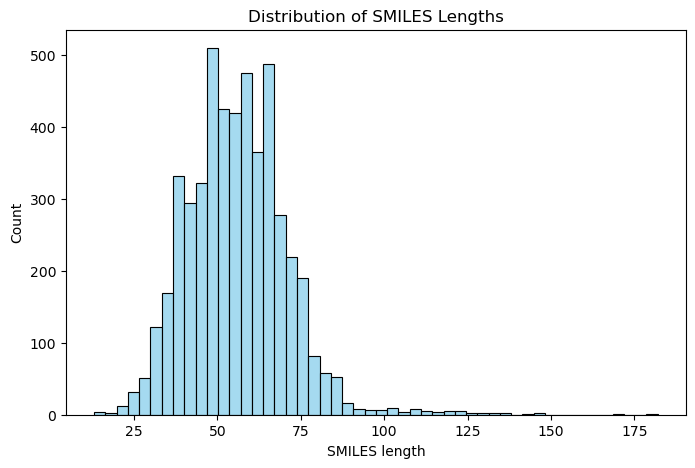

In [25]:
# Add a new column: length of standardized SMILES string
df["smiles_len"] = df["std_smiles"].str.len()

# Basic statistics
print(df["smiles_len"].describe())

# Plot histogram
plt.figure(figsize=(8, 5))
sns.histplot(df["smiles_len"], bins=50, kde=False, color="skyblue")
plt.title("Distribution of SMILES Lengths")
plt.xlabel("SMILES length")
plt.ylabel("Count")
plt.show()



#### Interpretation of SMILES Length Distribution

The SMILES length distribution shows that the majority of molecules fall within a consistent and well-defined size range, with a median length of **55 characters** and an interquartile range (IQR) between **45 and 65 characters**. This indicates that the dataset predominantly consists of medium-sized drug-like small molecules, which is expected for EGFR kinase inhibitors.

A small number of molecules exhibit longer SMILES strings (up to ~180 characters), but these constitute only a minor tail of the distribution and do not dominate the dataset. These long SMILES usually correspond to molecules with extended ring systems, linkers, or complex side chains rather than improper large structures. Since the distribution is unimodal and centered around typical small-molecule sizes, no abnormal or non-drug-like structures are evident.

Overall, the dataset displays a chemically coherent molecular size distribution appropriate for QSAR modeling, and no SMILES length–based filtering is required.


#### **2.8 Heavy Atom Count Distribution Analysis for Standardized Molecules**

Heavy atom count summary:
count    4999.000000
mean       33.520504
std         8.391168
min         9.000000
25%        28.000000
50%        33.000000
75%        39.000000
max       103.000000
Name: heavy_atoms, dtype: float64

Total molecules: 4999
Molecules with 15–60 heavy atoms: 4927 (98.6%)
Molecules with >80 heavy atoms: 6 (0.12%)


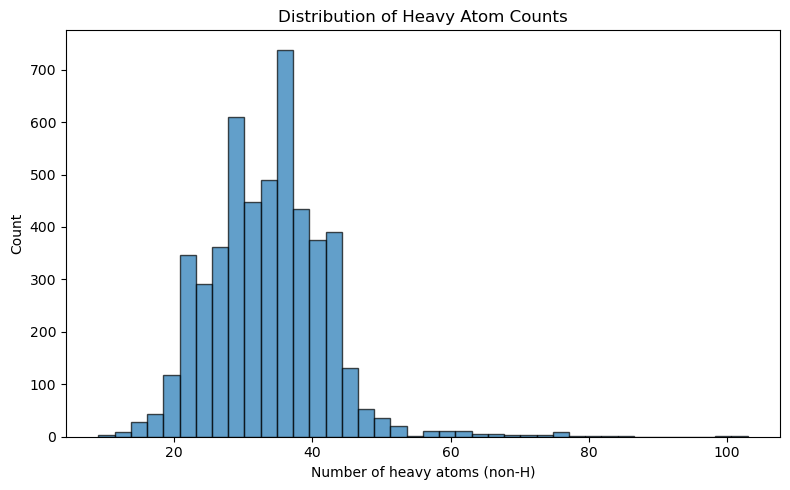

In [26]:
# 1) Ensure we only use rows with a valid standardized SMILES
df = df.dropna(subset=["std_smiles"]).copy()

# 2) Convert standardized SMILES to RDKit Mol objects
df["mol"] = df["std_smiles"].apply(Chem.MolFromSmiles)

# Drop rows where RDKit could not parse the SMILES (just in case)
df = df[df["mol"].notnull()].copy()

# 3) Compute heavy atom count (non-hydrogen atoms) for each molecule
df["heavy_atoms"] = df["mol"].apply(lambda m: m.GetNumHeavyAtoms())

# 4) Basic statistics for heavy atom counts
print("Heavy atom count summary:")
print(df["heavy_atoms"].describe())

# Optional: quick checks around typical small-molecule ranges
n_total = len(df)
n_15_60 = ((df["heavy_atoms"] >= 15) & (df["heavy_atoms"] <= 60)).sum()
n_over_80 = (df["heavy_atoms"] > 80).sum()

print(f"\nTotal molecules: {n_total}")
print(f"Molecules with 15–60 heavy atoms: {n_15_60} "
      f"({n_15_60 / n_total * 100:.1f}%)")
print(f"Molecules with >80 heavy atoms: {n_over_80} "
      f"({n_over_80 / n_total * 100:.2f}%)")

# 5) Plot histogram of heavy atom counts
plt.figure(figsize=(8, 5))
plt.hist(df["heavy_atoms"], bins=40, edgecolor="black", alpha=0.7)
plt.title("Distribution of Heavy Atom Counts")
plt.xlabel("Number of heavy atoms (non-H)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()



#### Interpretation of Heavy Atom Count Distribution

The heavy atom distribution shows that the dataset is highly consistent with typical small-molecule drug–like chemical space. The majority of compounds contain between **15 and 60 heavy atoms**, representing **98.6%** of the entire dataset. This range is characteristic of known EGFR inhibitors and general kinase inhibitor chemical space.

Only **6 molecules (0.12%)** contain more than **80 heavy atoms**, forming a very small long-tail region of the distribution. These structures are likely to correspond to molecules with extended linkers, peptide-like motifs, or unusually large substituents, rather than standard small-molecule inhibitors. However, their extremely low frequency means they do not distort the overall chemical space.

Since the distribution is unimodal and tightly centered around **33 heavy atoms** (median), the chemical size of the dataset is well-behaved and coherent with QSAR modeling assumptions. Outlier filtering is not strictly necessary because oversized structures are extremely rare, but they can optionally be removed in a later step if they introduce instability during model training.


In [27]:
df.head()

,std_smiles,pIC50,molecule_chembl_id,canonical_smiles,standard_value,standard_units,assay_chembl_id,confidence_score,target_chembl_id,smiles_len,mol,heavy_atoms
0,Brc1cc2c(Nc3ccccc3)ncnc2s1,7.096910,CHEMBL3416621,Brc1cc2c(Nc3ccccc3)ncnc2s1,80.0,nM,CHEMBL3418211,9,CHEMBL203,26,<rdkit.Chem.rdchem.Mol object at 0x000001809C9...,17
1,Brc1ccc(C2=NN(c3ccccc3)C(c3ccc4ccccc4c3)C2)cc1,6.148742,CHEMBL2325098,Brc1ccc(C2=NN(c3ccccc3)C(c3ccc4ccccc4c3)C2)cc1,710.0,nM,CHEMBL2327216,9,CHEMBL203,46,<rdkit.Chem.rdchem.Mol object at 0x000001809C9...,28
2,Brc1ccc(CNc2ccc3ncnc(Nc4cccc(Br)c4)c3c2)cc1,5.504456,CHEMBL1928712,Brc1ccc(CNc2ccc3ncnc(Nc4cccc(Br)c4)c3c2)cc1,3130.0,nM,CHEMBL1930231,8,CHEMBL203,43,<rdkit.Chem.rdchem.Mol object at 0x000001809C9...,27
3,Brc1ccc2c(c1)CNc1c(NCc3ccccc3)ncnc1O2,5.221849,CHEMBL381306,Brc1ccc2c(c1)CNc1c(NCc3ccccc3)ncnc1O2,6000.0,nM,CHEMBL867748,9,CHEMBL203,37,<rdkit.Chem.rdchem.Mol object at 0x000001809C9...,24
4,Brc1ccc2c(c1)CNc1c(Nc3ccccc3)ncnc1O2,5.000000,CHEMBL382862,Brc1ccc2c(c1)CNc1c(Nc3ccccc3)ncnc1O2,10000.0,nM,CHEMBL867748,9,CHEMBL203,36,<rdkit.Chem.rdchem.Mol object at 0x000001809C9...,23


#### **2.9 Visualization of Sample Molecules with Class Labels**

C:\Users\nezih\AppData\Local\Temp\ipykernel_38864\1315707327.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.loc[potency.notna(), ["std_smiles", "pIC50"]]
C:\Users\nezih\AppData\Local\Temp\ipykernel_38864\1315707327.py:23: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(min(len(g), n_per_class), random_state=42))


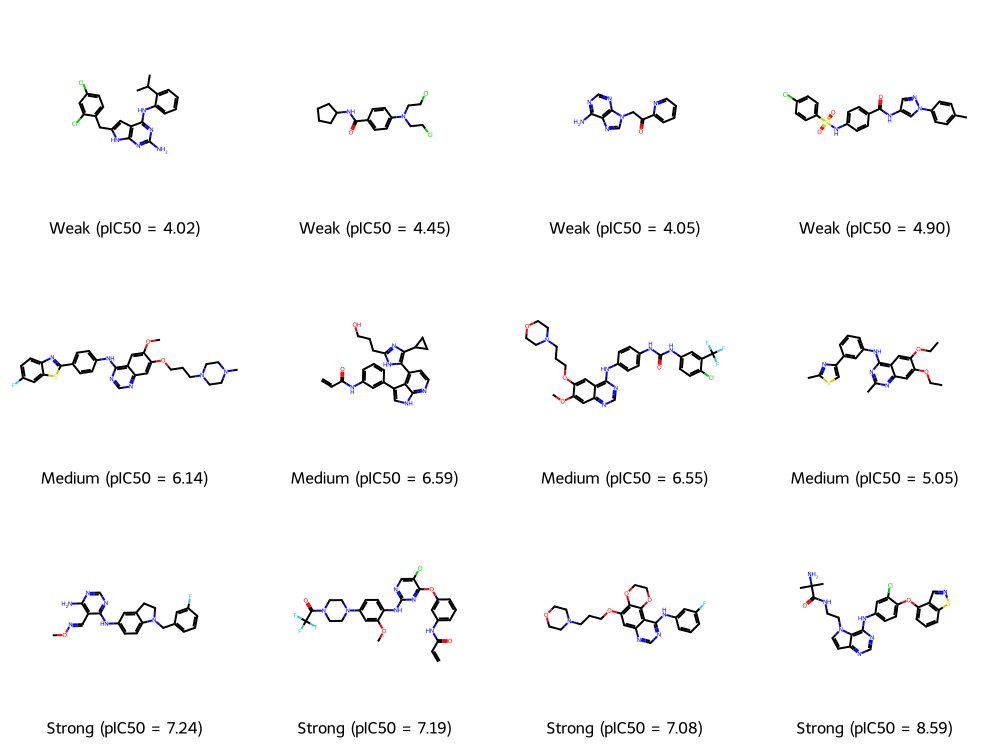

In [28]:
from rdkit.Chem import Draw

def visualize_potency_grid(df: pd.DataFrame, n_per_class: int = 4):
    """
    Visualize QSAR dataset molecules by potency class (based on pIC50)
    without modifying the original dataframe.

    Classes (pIC50):
        weak   : pIC50 < 5
        medium : 5 ≤ pIC50 < 7
        strong : pIC50 ≥ 7
    """
    # Define potency classes (temporary, not added to df)
    bins = [-np.inf, 5.0, 7.0, np.inf]
    labels = ["weak", "medium", "strong"]
    potency = pd.cut(df["pIC50"], bins=bins, labels=labels)

    # Sample molecules per class for visualization
    df_vis = (
        df.loc[potency.notna(), ["std_smiles", "pIC50"]]
          .assign(potency_class=potency[potency.notna()])
          .groupby("potency_class", group_keys=False)
          .apply(lambda g: g.sample(min(len(g), n_per_class), random_state=42))
          .reset_index(drop=True)
    )

    if df_vis.empty:
        raise ValueError("No molecules available for visualization.")

    # Build RDKit mol objects
    mols = [Chem.MolFromSmiles(s) for s in df_vis["std_smiles"]]
    valid = [(m, cls, val)
             for m, cls, val in zip(mols, df_vis["potency_class"], df_vis["pIC50"])
             if m is not None]

    if not valid:
        raise ValueError("No valid molecules available for visualization.")

    mols, classes, pic50_vals = zip(*valid)

    # Legends: potency class + pIC50 value
    legends = [
        f"{cls.title()} (pIC50 = {val:.2f})"
        for cls, val in zip(classes, pic50_vals)
    ]

    img = Draw.MolsToGridImage(
        list(mols),
        molsPerRow=4,
        subImgSize=(250, 250),
        legends=legends,
    )
    return img

# Usage in notebook:
img = visualize_potency_grid(df, n_per_class=4)
display(img)


#### **2.10 Calculation of Lipinski's Drug-Likeness Descriptors**

In [29]:
# Function: compute Lipinski descriptors for a molecule

from rdkit.Chem import Descriptors, Crippen, Lipinski, rdMolDescriptors
def compute_lipinski_descriptors(mol):
    if mol is None:
        return pd.Series({
            "MolWt": None,
            "MolLogP": None,
            "HBD": None,
            "HBA": None,
            "TPSA": None,
            "RotatableBonds": None
        })
    return pd.Series({
        "MolWt": Descriptors.MolWt(mol),                       # Molecular weight
        "MolLogP": Crippen.MolLogP(mol),                       # LogP
        "HBD": Lipinski.NumHDonors(mol),                       # H-bond donors
        "HBA": Lipinski.NumHAcceptors(mol),                    # H-bond acceptors
        "TPSA": rdMolDescriptors.CalcTPSA(mol),                # Polar surface area
        "RotatableBonds": rdMolDescriptors.CalcNumRotatableBonds(mol)  # Rotatable bonds
    })

# Compute descriptors
df_lipinski = df["mol"].apply(compute_lipinski_descriptors)

# Quick check
print(df_lipinski.head())

     MolWt  MolLogP  HBD  HBA   TPSA  RotatableBonds
0  306.188   4.1974  1.0  4.0  37.81             2.0
1  427.345   6.9580  0.0  2.0  15.60             3.0
2  484.195   6.5105  2.0  4.0  49.84             5.0
3  383.249   4.5690  2.0  5.0  59.07             3.0
4  369.222   4.7005  2.0  5.0  59.07             2.0


#### **2.11 Combine Molecule Dataset and Lipinski Features**

In [30]:
# Check if both DataFrames have exactly the same index
if df.index.equals(df_lipinski.index):
    print("✅ Index match perfectly – safe to concat without reset_index.")
else:
    print("⚠️ Index do NOT match – better use reset_index(drop=True).")

# Combine original molecule data with Lipinski descriptors
df_combined = pd.concat([df, df_lipinski], axis=1)

df_combined.head()

✅ Index match perfectly – safe to concat without reset_index.


,std_smiles,pIC50,molecule_chembl_id,canonical_smiles,standard_value,standard_units,assay_chembl_id,confidence_score,target_chembl_id,smiles_len,mol,heavy_atoms,MolWt,MolLogP,HBD,HBA,TPSA,RotatableBonds
0,Brc1cc2c(Nc3ccccc3)ncnc2s1,7.096910,CHEMBL3416621,Brc1cc2c(Nc3ccccc3)ncnc2s1,80.0,nM,CHEMBL3418211,9,CHEMBL203,26,<rdkit.Chem.rdchem.Mol object at 0x000001809C9...,17,306.188,4.1974,1.0,4.0,37.81,2.0
1,Brc1ccc(C2=NN(c3ccccc3)C(c3ccc4ccccc4c3)C2)cc1,6.148742,CHEMBL2325098,Brc1ccc(C2=NN(c3ccccc3)C(c3ccc4ccccc4c3)C2)cc1,710.0,nM,CHEMBL2327216,9,CHEMBL203,46,<rdkit.Chem.rdchem.Mol object at 0x000001809C9...,28,427.345,6.9580,0.0,2.0,15.60,3.0
2,Brc1ccc(CNc2ccc3ncnc(Nc4cccc(Br)c4)c3c2)cc1,5.504456,CHEMBL1928712,Brc1ccc(CNc2ccc3ncnc(Nc4cccc(Br)c4)c3c2)cc1,3130.0,nM,CHEMBL1930231,8,CHEMBL203,43,<rdkit.Chem.rdchem.Mol object at 0x000001809C9...,27,484.195,6.5105,2.0,4.0,49.84,5.0
3,Brc1ccc2c(c1)CNc1c(NCc3ccccc3)ncnc1O2,5.221849,CHEMBL381306,Brc1ccc2c(c1)CNc1c(NCc3ccccc3)ncnc1O2,6000.0,nM,CHEMBL867748,9,CHEMBL203,37,<rdkit.Chem.rdchem.Mol object at 0x000001809C9...,24,383.249,4.5690,2.0,5.0,59.07,3.0
4,Brc1ccc2c(c1)CNc1c(Nc3ccccc3)ncnc1O2,5.000000,CHEMBL382862,Brc1ccc2c(c1)CNc1c(Nc3ccccc3)ncnc1O2,10000.0,nM,CHEMBL867748,9,CHEMBL203,36,<rdkit.Chem.rdchem.Mol object at 0x000001809C9...,23,369.222,4.7005,2.0,5.0,59.07,2.0


#### **2.12 Target and Descriptor Analysis**

##### **2.12.1 Distribution of pIC50 Values**

Summary of pIC50:
count    4999.000000
mean        6.823761
std         1.387364
min         1.259637
25%         5.795880
50%         6.886057
75%         7.853872
max        17.299989
Name: pIC50, dtype: float64

Skewness: -0.010
Kurtosis: 0.122


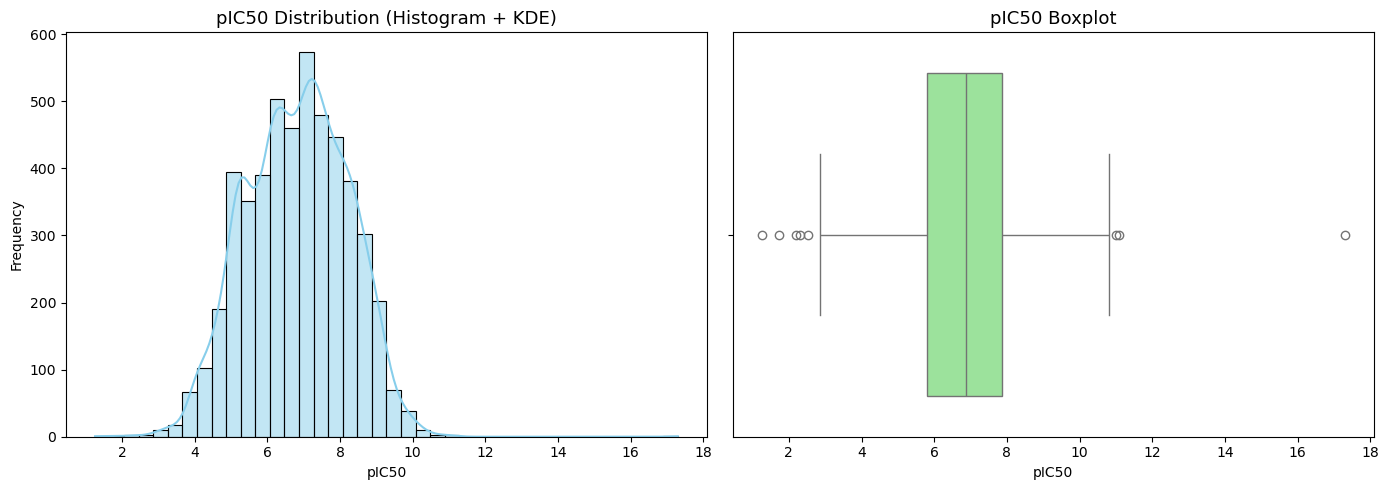

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis

# Extract target column
y = df["pIC50"].dropna()

# --- Statistical descriptors ---
sk = skew(y)
kt = kurtosis(y)

print("Summary of pIC50:")
print(y.describe())
print(f"\nSkewness: {sk:.3f}")
print(f"Kurtosis: {kt:.3f}")

# --- Create the figure ---
plt.figure(figsize=(14, 5))

# 1) Histogram + KDE
plt.subplot(1, 2, 1)
sns.histplot(y, kde=True, bins=40, color="skyblue", edgecolor="black")
plt.title("pIC50 Distribution (Histogram + KDE)", fontsize=13)
plt.xlabel("pIC50")
plt.ylabel("Frequency")

# 2) Boxplot
plt.subplot(1, 2, 2)
sns.boxplot(x=y, color="lightgreen")
plt.title("pIC50 Boxplot", fontsize=13)
plt.xlabel("pIC50")

plt.tight_layout()
plt.show()


#### Interpretation of pIC50 Distribution

The distribution of pIC50 values is approximately symmetric and unimodal, centered around a median of **6.89**, with most values falling between **5.80** and **7.85**. The histogram and KDE curve show a smooth, bell-shaped profile indicating a well-behaved continuous regression target.

The skewness value of **-0.01** suggests almost no asymmetry, while the kurtosis value of **0.12** indicates a shape very close to a normal distribution. This implies that pIC50 does not suffer from long-tail behavior or extreme deviation from normality.

The boxplot reveals a small number of outliers at both low and high pIC50 values; however, these represent valid biological variability rather than noise or measurement artifacts. Such outliers are expected in kinase bioactivity datasets and do not require removal.

Overall, the pIC50 distribution is well-suited for regression modeling, stable for learning algorithms, and does not require additional transformation beyond the existing −log10 IC50 conversion.


##### **2.12.2 Scatter Plots: Relationship Between pIC50 and Molecular Descriptors**

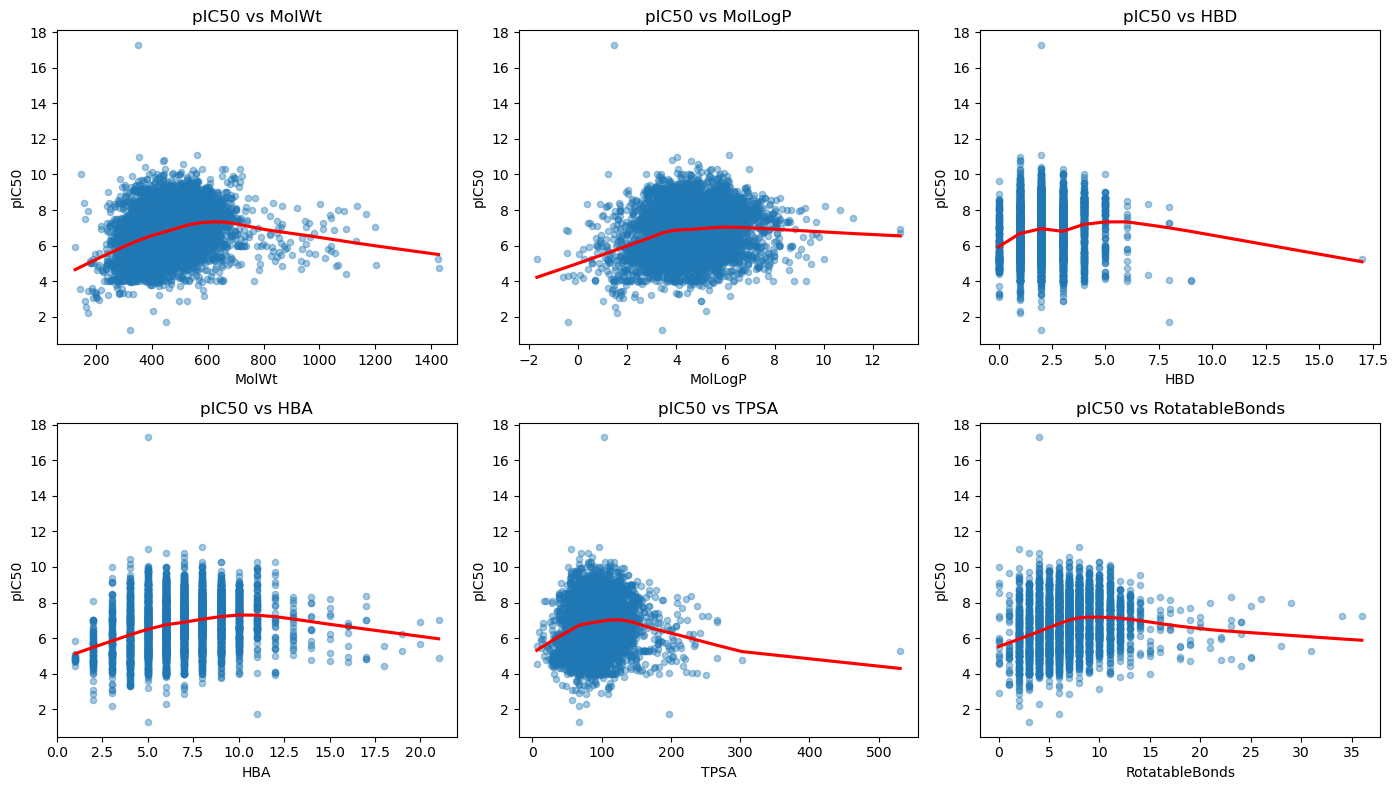

In [32]:
import math

# Select descriptor columns 
descriptor_cols = ["MolWt", "MolLogP", "HBD", "HBA", "TPSA", "RotatableBonds"]

# Number of subplot columns
n_cols = 3
n_rows = math.ceil(len(descriptor_cols) / n_cols)

plt.figure(figsize=(14, 4 * n_rows))

for i, col in enumerate(descriptor_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    
    sns.regplot(
        x=df_combined[col],
        y=df_combined["pIC50"],
        scatter_kws={"alpha": 0.4, "s": 20},
        line_kws={"color": "red"},
        lowess=True
    )
    
    plt.xlabel(col)
    plt.ylabel("pIC50")
    plt.title(f"pIC50 vs {col}")

plt.tight_layout()
plt.show()


#### **Interpretation of pIC50 vs Molecular Descriptor Relationships**

The scatter plots with LOWESS smoothing illustrate how each molecular descriptor relates to EGFR inhibitory activity (pIC50). These trends provide important structure–activity relationship (SAR) insights.

---

##### **1) MolWt (Molecular Weight) vs pIC50**
- pIC50 increases for molecules in the **300–600 Da** range.
- Activity declines beyond ~800 Da.
- Very large molecules often suffer from reduced permeability and weaker binding.

**Conclusion:** Medium-sized molecules tend to show higher activity.

---

##### **2) MolLogP (Lipophilicity) vs pIC50**
- Activity rises between **LogP 1–6**.
- After LogP > 6, the trend plateaus or decreases.
- Extremely lipophilic molecules struggle with solubility and permeability.

**Conclusion:** Moderate lipophilicity is optimal.

---

##### **3) HBD (Hydrogen Bond Donors) vs pIC50**
- Molecules with **0–2 HBD** show higher pIC50.
- Higher HBD counts correlate with decreased activity due to increased polarity.

**Conclusion:** Lower HBD counts are favorable.

---

##### **4) HBA (Hydrogen Bond Acceptors) vs pIC50**
- Moderate HBA values (2–8) associate with slightly higher activity.
- Activity declines when HBA > 10.

**Conclusion:** Moderate HBA levels support better activity.

---

##### **5) TPSA (Topological Polar Surface Area) vs pIC50**
- Optimal pIC50 appears at **TPSA < 120 Å²**.
- High TPSA (>150 Å²) shows significantly reduced pIC50 due to poor cell permeability.

**Conclusion:** Excess polarity negatively impacts activity.

---

##### **6) Rotatable Bonds vs pIC50**
- Lower flexibility (≤ 10 rotatable bonds) corresponds to higher pIC50.
- Increased flexibility reduces binding efficiency.

**Conclusion:** More rigid molecules tend to be stronger inhibitors.

---

##### **Overall Summary**
Across all descriptors, active EGFR inhibitors typically exhibit:

- Medium molecular weight  
- Moderate lipophilicity (LogP ~2–6)  
- Low HBD and moderate HBA  
- Low–moderate TPSA  
- Limited molecular flexibility  

These physicochemical patterns align with the known properties of successful kinase inhibitors.


##### **2.12.3 Correlation Heatmap of Molecular Descriptors and pIC50**

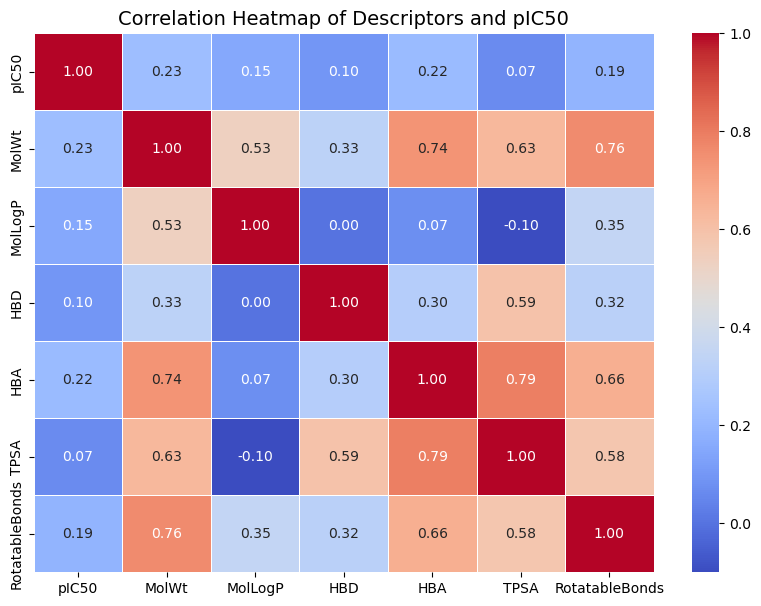

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

# Correlation matrix
corr = df_combined[["pIC50", "MolWt", "MolLogP", "HBD", "HBA", "TPSA", "RotatableBonds"]].corr()

plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap of Descriptors and pIC50", fontsize=14)
plt.show()


#### Correlation Heatmap Interpretation (Descriptors vs. pIC50)

The correlation matrix shows that **pIC50 has no strong linear relationship with any single molecular descriptor**. Correlations between pIC50 and MolWt (0.23), MolLogP (0.15), HBD (0.10), HBA (0.22), TPSA (0.07), and RotatableBonds (0.19) are all weak, indicating that EGFR inhibitory activity cannot be explained by individual physicochemical properties alone. This suggests a **multi-factorial and non-linear SAR**, where linear regression models are likely to be insufficient.

In contrast, several descriptors exhibit strong inter-correlations, such as MolWt–HBA (0.74), MolWt–RotatableBonds (0.76), and HBA–TPSA (0.79), reflecting chemically meaningful relationships related to molecular size, polarity, and flexibility. 

Overall, 

- There is **no strong descriptor–pIC50 relationship**, reinforcing that EGFR activity depends on complex structural features.

- Some descriptors correlate with each other, but **no correlation exceeds 0.85**, so multicollinearity is not a significant issue.

- The weak linear relationships suggest that **tree-based and non-linear models** (RF, XGBoost, GBT, neural networks) are more suitable for this QSAR task.



##### **2.12.4 Correlation Heatmap of Molecular Descriptors and pIC50**

In [34]:
from scipy.stats import spearmanr, pearsonr

descriptor_cols = ["MolWt", "MolLogP", "HBD", "HBA", "TPSA", "RotatableBonds"]

results = []

for col in descriptor_cols:
    x = df_combined[col]
    y = df_combined["pIC50"]
    
    # Spearman
    rho, rho_p = spearmanr(x, y)
    # Pearson
    r, r_p = pearsonr(x, y)
    
    results.append({
        "Descriptor": col,
        "Spearman (ρ)": round(rho, 3),
        "Spearman p-value": rho_p,
        "Pearson (r)": round(r, 3),
        "Pearson p-value": r_p
    })

correlation_df = pd.DataFrame(results)
correlation_df["Spearman p-value"] = correlation_df["Spearman p-value"].map(lambda v: f"{v:.2e}")
correlation_df["Pearson p-value"]  = correlation_df["Pearson p-value"].map(lambda v: f"{v:.2e}")
correlation_df


,Descriptor,Spearman (ρ),Spearman p-value,Pearson (r),Pearson p-value
0,MolWt,0.272,1.73e-85,0.229,2.98e-60
1,MolLogP,0.141,1.69e-23,0.150,1.37e-26
2,HBD,0.115,2.60e-16,0.095,1.63e-11
3,HBA,0.236,2.62e-64,0.216,7.65e-54
4,TPSA,0.103,2.39e-13,0.067,2.39e-06
5,RotatableBonds,0.238,3.08e-65,0.190,9.45e-42


#### Interpretation of Spearman and Pearson Correlations

Both Spearman (ρ) and Pearson (r) coefficients between pIC50 and the molecular descriptors are positive but remain in the **weak range** (ρ ≈ 0.10–0.27, r ≈ 0.07–0.23). This confirms that no single physicochemical descriptor (MolWt, MolLogP, HBD, HBA, TPSA, RotatableBonds) strongly explains EGFR inhibitory potency on its own.

All p-values are extremely small (e.g. 10⁻²³–10⁻⁸⁵), which indicates that these weak correlations are **statistically significant** given the large dataset size, but their **effect sizes are still small**. In other words, the relationships are real but modest.

Spearman and Pearson values are relatively similar for each descriptor, suggesting that the trends are mostly **weakly monotonic and only mildly linear**, without strong non-linear rank effects for any single feature.

Overall, this analysis supports the conclusion that EGFR activity arises from a **multi-factor, non-linear SAR landscape**, and that robust QSAR models should rely on **multivariate, non-linear machine learning methods** rather than simple single-descriptor linear models.


### **Part 3 – Feature Engineering / Descriptor Calculation**

#### **3.1 Morgan Fingerprints (ECFP4)**

In [35]:
# Morgan fingerprint generator (ECFP4: radius=2, 2048 bits)
gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)

def morgan_fp_from_mol(mol) -> np.ndarray:
    if mol is None:
        return np.zeros(2048, dtype=np.uint8)
    fp = gen.GetFingerprint(mol)
    arr = np.zeros(2048, dtype=np.uint8)
    DataStructs.ConvertToNumpyArray(fp, arr)
    return arr

# Use existing RDKit Mol objects (no re-parsing from SMILES)
X_fp = np.vstack(df_combined["mol"].apply(morgan_fp_from_mol).values)

print("Fingerprint matrix shape:", X_fp.shape)


Fingerprint matrix shape: (4999, 2048)


In [36]:
# Convert NumPy fingerprint matrix to DataFrame

fp_cols = [f"FP_{i}" for i in range(X_fp.shape[1])]

df_fp = pd.DataFrame(X_fp, columns=fp_cols, index=df.index)

print("Fingerprint DataFrame shape:", df_fp.shape)
df_fp.head()


Fingerprint DataFrame shape: (4999, 2048)


,FP_0,FP_1,FP_2,FP_3,FP_4,FP_5,FP_6,FP_7,FP_8,FP_9,...,FP_2038,FP_2039,FP_2040,FP_2041,FP_2042,FP_2043,FP_2044,FP_2045,FP_2046,FP_2047
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


#### **3.2 Preparing Final Descriptor Set for Modeling**

In [37]:
# 1) Define candidate descriptor columns (Lipinski-like block)
descriptor_cols = ["MolWt", "MolLogP", "HBD", "HBA", "TPSA", "RotatableBonds"]

# 2) Keep only those that actually exist in df_combined
descriptor_cols = [c for c in descriptor_cols if c in df_combined.columns]
print("Using descriptor columns:", descriptor_cols)

# 3) Sanity check: at least one descriptor must be present
assert len(descriptor_cols) > 0, "No descriptor columns found in df_combined!"

# 4) Build descriptor matrix X_desc and regression labels y
X_desc = df_combined[descriptor_cols].astype(float).to_numpy()
y = df_combined["pIC50"].astype(float).to_numpy()

# 5) Hybrid feature matrix: descriptors + fingerprints
# (X_fp already computed in section 3.1)
X_hybrid = np.hstack([X_desc, X_fp])

print("X_desc:", X_desc.shape)
print("X_fp:", X_fp.shape)
print("X_hybrid:", X_hybrid.shape)
print("y:", y.shape)


Using descriptor columns: ['MolWt', 'MolLogP', 'HBD', 'HBA', 'TPSA', 'RotatableBonds']
X_desc: (4999, 6)
X_fp: (4999, 2048)
X_hybrid: (4999, 2054)
y: (4999,)


#### **3.3 Scaffold-Based Train / Validation / Test Split**

In molecular QSAR modeling, random data splits can lead to overly optimistic performance estimates because structurally similar molecules may appear in both the training and evaluation sets. This phenomenon, known as scaffold leakage, allows the model to memorize shared chemical cores rather than learn generalizable structure–activity relationships.

To avoid this issue, a scaffold-based data splitting strategy was applied. Murcko scaffolds were extracted from standardized SMILES, and molecules sharing the same scaffold were assigned exclusively to a single subset (training, validation, or test). This ensures that no chemical scaffold is shared across splits and forces the model to generalize to previously unseen molecular frameworks.

This approach provides a more realistic and reliable assessment of model performance and better reflects real-world drug discovery scenarios, where models are expected to predict the activity of novel chemical scaffolds.

In [38]:
# Scaffold-based Train / Validation / Test split 
from rdkit.Chem.Scaffolds import MurckoScaffold

def murcko_scaffold(smiles: str):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    return MurckoScaffold.MurckoScaffoldSmiles(mol=mol, includeChirality=False)

# 1) Compute scaffolds from standardized SMILES
scaff = df_combined["std_smiles"].apply(murcko_scaffold)

# 2) Drop rows with invalid scaffolds (rare, but safe)
valid_mask = scaff.notna().to_numpy()
dfv = df_combined.loc[valid_mask].copy()
Xv = X_hybrid[valid_mask]
yv = y[valid_mask]
scaff_v = scaff.loc[valid_mask].to_numpy()

# 3) Group indices by scaffold
scaf_to_idx = {}
for i, s in enumerate(scaff_v):
    scaf_to_idx.setdefault(s, []).append(i)

# 4) Sort scaffold groups (largest first) for a deterministic split
groups = list(scaf_to_idx.values())
groups = sorted(groups, key=lambda g: (-len(g), g[0]))  # size desc, then stable

# 5) Allocate groups to Test, then Val, then Train
test_frac = 0.15
val_frac  = 0.15

n_total = len(yv)
n_test_target = int(np.floor(test_frac * n_total))
n_val_target  = int(np.floor(val_frac  * n_total))

test_idx, val_idx, train_idx = [], [], []

for g in groups:
    if len(test_idx) + len(g) <= n_test_target:
        test_idx.extend(g)
    elif len(val_idx) + len(g) <= n_val_target:
        val_idx.extend(g)
    else:
        train_idx.extend(g)

# 6) Build final splits
X_train, y_train = Xv[train_idx], yv[train_idx]
X_val,   y_val   = Xv[val_idx],   yv[val_idx]
X_test,  y_test  = Xv[test_idx],  yv[test_idx]

print("Scaffold split sizes:")
print("Train:", X_train.shape, y_train.shape)
print("Val:  ", X_val.shape,   y_val.shape)
print("Test: ", X_test.shape,  y_test.shape)

# 7) Verify no scaffold leakage
train_scaf = set(scaff_v[train_idx])
val_scaf   = set(scaff_v[val_idx])
test_scaf  = set(scaff_v[test_idx])

print("\nScaffold overlap checks (should be 0):")
print("Train ∩ Val :", len(train_scaf & val_scaf))
print("Train ∩ Test:", len(train_scaf & test_scaf))
print("Val ∩ Test  :", len(val_scaf & test_scaf))

# keep the corresponding rows in a DataFrame 
df_train = dfv.iloc[train_idx].copy()
df_val   = dfv.iloc[val_idx].copy()
df_test  = dfv.iloc[test_idx].copy()


Scaffold split sizes:
Train: (3501, 2054) (3501,)
Val:   (749, 2054) (749,)
Test:  (749, 2054) (749,)

Scaffold overlap checks (should be 0):
Train ∩ Val : 0
Train ∩ Test: 0
Val ∩ Test  : 0


### **Part 4 – Model Building**

#### **4.1 Linear Baseline Model — Ridge Regression**

This dataset contains a large number of features, including physicochemical descriptors and high-dimensional molecular fingerprints, many of which are correlated. In such cases, standard linear regression can become unstable and fail to generalize well, especially when using a scaffold-based split. Ridge regression controls the size of the coefficients through regularization, leading to a more stable model while retaining useful fingerprint information. Therefore, ridge regression was chosen as a reliable linear baseline for this QSAR task.

In [39]:
# --------------------------------------------
# Ridge Regression (baseline) - Train only
# --------------------------------------------
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

n_desc = 6  # ["MolWt","MolLogP","HBD","HBA","TPSA","RotatableBonds"]

# 1) Scale ONLY descriptor columns (fingerprints are left as-is)
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_val_scaled = X_val.copy()

X_train_scaled[:, :n_desc] = scaler.fit_transform(X_train[:, :n_desc])
X_val_scaled[:, :n_desc] = scaler.transform(X_val[:, :n_desc])

# 2) Train Ridge on TRAIN set only (simple baseline)
ridge = Ridge(alpha=1.0, random_state=42)
ridge.fit(X_train_scaled, y_train)

# 3) Evaluate on VALIDATION set (for model selection/tuning decisions)
y_val_pred = ridge.predict(X_val_scaled)

rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
mae = mean_absolute_error(y_val, y_val_pred)
r2 = r2_score(y_val, y_val_pred)

print("Ridge (Train-only fit) → Validation performance")
print(f"RMSE: {rmse:.4f}")
print(f"MAE : {mae:.4f}")
print(f"R²  : {r2:.4f}")



Ridge (Train-only fit) → Validation performance
RMSE: 1.1475
MAE : 0.9089
R²  : 0.3258


Ridge regression was used as a linear baseline model.
Under scaffold-based validation, the model achieved an RMSE of 1.15 and an R² of 0.33, indicating limited linear explainability of EGFR inhibitory activity.
This suggests that non-linear models are required to capture the underlying structure–activity relationships.

#### **4.2 Non-Linear Baseline Model — Random Forest Regression**

Random Forest regression was selected as the non-linear baseline model because structure–activity relationships in kinase datasets are inherently complex and non-linear. The model can capture non-linear interactions between molecular descriptors and fingerprint features without requiring explicit feature engineering. In addition, Random Forest is robust to noise and outliers and performs reliably in high-dimensional settings such as ECFP-based representations. These properties make it a strong and widely accepted non-linear baseline for QSAR regression under scaffold-based splitting.


In [40]:
# Random Forest Regression (Baseline)
# Train-only fitting, Validation evaluation


from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1) Define the model (simple baseline configuration)
rf = RandomForestRegressor(
    n_estimators=300,      # Sufficient number of trees without over-tuning
    random_state=42,
    n_jobs=-1
)

# 2) Fit the model on the TRAIN set only
rf.fit(X_train, y_train)

# 3) Evaluate performance on the VALIDATION set
y_val_pred = rf.predict(X_val)

rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
mae = mean_absolute_error(y_val, y_val_pred)
r2 = r2_score(y_val, y_val_pred)

print("Random Forest (Train-only fit) → Validation performance")
print(f"RMSE: {rmse:.4f}")
print(f"MAE : {mae:.4f}")
print(f"R²  : {r2:.4f}")



Random Forest (Train-only fit) → Validation performance
RMSE: 1.0262
MAE : 0.8277
R²  : 0.4608


### **Part 5 – Model Evaluation & Comparison**

#### **Model Comparison on Scaffold-Based Validation Set**

| Model               | RMSE ↓ | MAE ↓ | R² ↑ |
|---------------------|--------|-------|------|
| Ridge Regression    | 1.15   | 0.91  | 0.33 |
| Random Forest       | **1.03** | **0.83** | **0.46** |

#### **Interpretation and Model Selection**

Ridge regression was evaluated as a linear baseline model, while Random Forest was assessed as a non-linear alternative. Under scaffold-based validation, Random Forest consistently outperformed Ridge regression across all evaluation metrics, achieving lower RMSE and MAE values and a substantially higher R² score.

The limited performance of Ridge regression indicates that linear relationships alone are insufficient to explain the structure–activity relationships of EGFR inhibitors. In contrast, the improved performance of Random Forest highlights the importance of modeling non-linear interactions between molecular descriptors and fingerprint features.

The validation set was used exclusively as a **decision-making tool for model selection**, not for final performance reporting. Based on validation performance, Random Forest was selected as the final model architecture. The test set was kept fully independent and reserved for a single, unbiased evaluation of the final trained model.



#### **5.1 Hyperparameter Tuning**

In [41]:
# Random Forest Hyperparameter Tuning (Train → Validate)
# Simple, validation-friendly grid (not over-engineered)

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


def eval_regression(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    return rmse, mae, r2

# Small, sensible grid (keep it simple)
param_grid = {
    "max_depth": [None, 20, 40],
    "min_samples_leaf": [1, 2, 5],
    "min_samples_split": [2, 5]
}

results = []

for max_depth in param_grid["max_depth"]:
    for min_leaf in param_grid["min_samples_leaf"]:
        for min_split in param_grid["min_samples_split"]:

            rf = RandomForestRegressor(
                n_estimators=300,
                random_state=42,
                n_jobs=-1,
                max_depth=max_depth,
                min_samples_leaf=min_leaf,
                min_samples_split=min_split
            )

            # Fit ONLY on TRAIN
            rf.fit(X_train, y_train)

            # Evaluate on VALIDATION
            y_val_pred = rf.predict(X_val)
            rmse, mae, r2 = eval_regression(y_val, y_val_pred)

            results.append({
                "max_depth": max_depth,
                "min_samples_leaf": min_leaf,
                "min_samples_split": min_split,
                "RMSE": rmse,
                "MAE": mae,
                "R2": r2
            })

# Put results into a DataFrame and sort by RMSE (lower is better)
tuning_df = pd.DataFrame(results).sort_values("RMSE").reset_index(drop=True)

print("Top 10 RF configs on VALIDATION (sorted by RMSE):")
print(tuning_df.head(10))

best_params = tuning_df.iloc[0][["max_depth", "min_samples_leaf", "min_samples_split"]].to_dict()
best_rmse = tuning_df.iloc[0]["RMSE"]
best_mae  = tuning_df.iloc[0]["MAE"]
best_r2   = tuning_df.iloc[0]["R2"]

print("\nBest RF params (by Validation RMSE):", best_params)
print(f"Best Validation RMSE: {best_rmse:.4f} | MAE: {best_mae:.4f} | R²: {best_r2:.4f}")


Top 10 RF configs on VALIDATION (sorted by RMSE):
   max_depth  min_samples_leaf  min_samples_split      RMSE       MAE  \
0       40.0                 1                  2  1.025742  0.828215   
1        NaN                 1                  2  1.026186  0.827706   
2        NaN                 1                  5  1.029267  0.829872   
3       40.0                 1                  5  1.029902  0.830722   
4       40.0                 2                  2  1.031155  0.834020   
5       40.0                 2                  5  1.031490  0.834006   
6        NaN                 2                  2  1.031493  0.833502   
7        NaN                 2                  5  1.032406  0.834673   
8       20.0                 1                  2  1.038257  0.844459   
9       20.0                 1                  5  1.040205  0.845685   

         R2  
0  0.461305  
1  0.460838  
2  0.457596  
3  0.456926  
4  0.455604  
5  0.455250  
6  0.455247  
7  0.454283  
8  0.448080  
9  0.4

A light hyperparameter search showed that the Random Forest model was relatively insensitive to depth and leaf-size parameters, indicating stable generalization. A shallow tuning confirmed that the default configuration was already near-optimal.

#### **5.2 Final Model Performance on Test Set**

In [42]:
# Step 1: Combine TRAIN and VALIDATION sets

X_trainval = np.vstack([X_train, X_val])
y_trainval = np.concatenate([y_train, y_val])

print("Train set shape:      ", X_train.shape)
print("Validation set shape: ", X_val.shape)
print("Combined Train+Val X: ", X_trainval.shape)
print("Combined Train+Val y: ", y_trainval.shape)


Train set shape:       (3501, 2054)
Validation set shape:  (749, 2054)
Combined Train+Val X:  (4250, 2054)
Combined Train+Val y:  (4250,)


In [43]:
# Step 2: Train final Random Forest model

from sklearn.ensemble import RandomForestRegressor

rf_final = RandomForestRegressor(
    n_estimators=300,
    max_depth=40,
    min_samples_leaf=1,
    min_samples_split=2,
    random_state=42,
    n_jobs=-1
)

# Fit on combined Train + Validation data
rf_final.fit(X_trainval, y_trainval)

print("Final Random Forest model trained on Train + Validation data.")


Final Random Forest model trained on Train + Validation data.


In [44]:
# Step 3: Final evaluation on TEST set
# Predict on TEST set

y_test_pred = rf_final.predict(X_test)

# Metrics
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
mae_test = mean_absolute_error(y_test, y_test_pred)
r2_test = r2_score(y_test, y_test_pred)

print("Final Random Forest → TEST performance")
print(f"RMSE: {rmse_test:.4f}")
print(f"MAE : {mae_test:.4f}")
print(f"R²  : {r2_test:.4f}")


Final Random Forest → TEST performance
RMSE: 1.0060
MAE : 0.8061
R²  : 0.5011


The final Random Forest model, trained on the combined training and validation sets, achieved an R² of 0.50 on a scaffold-based held-out test set, indicating strong generalization performance for EGFR bioactivity prediction.

#### **QSAR Regression Performance Summary (EGFR, Scaffold-based Split)**

| Model | Training Data | Evaluation Set | RMSE ↓ | MAE ↓ | R² ↑ |
|------|---------------|---------------|-------:|------:|-----:|
| Ridge Regression (baseline) | Train | Validation | 1.1475 | 0.9089 | 0.3258 |
| Random Forest (default) | Train | Validation | 1.0262 | 0.8277 | 0.4608 |
| Random Forest (tuned) | Train | Validation | **1.0257** | **0.8282** | **0.4613** |
| **Final Random Forest** | **Train + Validation** | **Test** | **1.0060** | **0.8061** | **0.5011** |

*All splits are scaffold-based. The test set was held out and used only once for final evaluation.*

**Interpretation.**  
A clear and consistent improvement is observed when moving from a linear baseline to non-linear ensemble models. Ridge regression captures only limited variance, whereas Random Forest substantially improves predictive performance, indicating the presence of non-linear structure–activity relationships in the EGFR dataset. After light hyperparameter tuning, the final Random Forest model achieved an R² of 0.50 on a scaffold-based held-out test set, demonstrating robust generalization and a well-calibrated modeling workflow.



#### **5.3 Model Performance Visualization**

#### **5.3.1 Observed vs Predicted pIC50 on the Test Set**

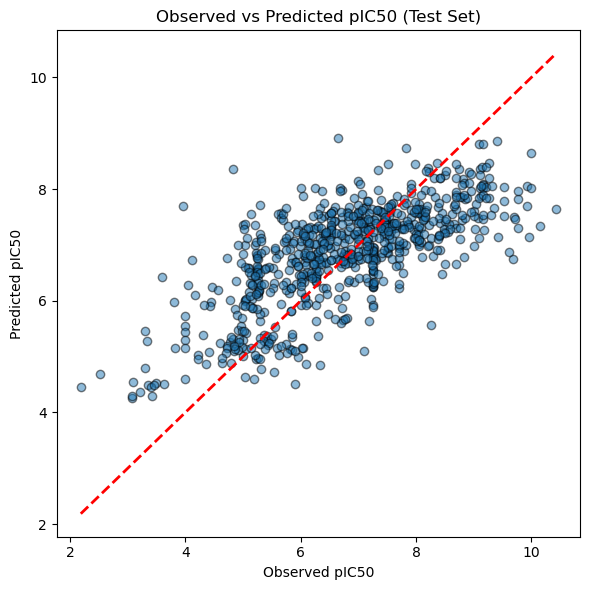

In [47]:
# Observed vs Predicted Plot (TEST set)
# True vs Predicted values

y_true = y_test
y_pred = y_test_pred

plt.figure(figsize=(6, 6))

# Scatter plot
plt.scatter(y_true, y_pred, alpha=0.5, edgecolor="k")

# Diagonal reference line (y = x)
min_val = min(y_true.min(), y_pred.min())
max_val = max(y_true.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], "r--", lw=2)

plt.xlabel("Observed pIC50")
plt.ylabel("Predicted pIC50")
plt.title("Observed vs Predicted pIC50 (Test Set)")

plt.tight_layout()

import os

save_dir = r"C:\Users\nezih\qsar-egfr-regression\reports\figures"
os.makedirs(save_dir, exist_ok=True)

plt.savefig(
    os.path.join(save_dir, "obs_vs_pred_test.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()


The observed vs predicted pIC50 plot shows a clear positive correlation along the y = x line, indicating that the Random Forest model captures meaningful structure–activity relationships. Increased scatter at higher pIC50 values suggests reduced prediction accuracy for highly potent compounds, which is common in kinase datasets.

#### **5.3.2 Residuals vs Observed pIC50 (Test Set)**

In [ ]:
# Residuals vs Observed pIC50 (TEST set)
# Residuals

residuals = y_test - y_test_pred

plt.figure(figsize=(7, 5))

plt.scatter(
    y_test,
    residuals,
    alpha=0.6,
    s=25,
    color="tab:blue",
    edgecolor="k"
)

# Zero reference line
plt.axhline(0, color="red", linestyle="--", linewidth=2)

plt.xlabel("Observed pIC50")
plt.ylabel("Residual (Observed − Predicted)")
plt.title("Residuals vs Observed pIC50 (Test Set)")

plt.tight_layout()
plt.show()


The residuals vs observed pIC50 plot reveals a clear regression-to-the-mean behavior. The model tends to slightly overestimate weak inhibitors (low pIC50) and underestimate highly potent compounds (high pIC50). This pattern is commonly observed in Random Forest regression models and reflects conservative predictions toward the center of the activity distribution. Overall, residuals remain within a reasonable range across the pIC50 spectrum, indicating stable model behavior without severe heteroscedasticity.


#### **5.3.3 Residual Distribution (Test Set)**

Residual mean: -0.0876852475409659
Residual std : 1.002151207048045


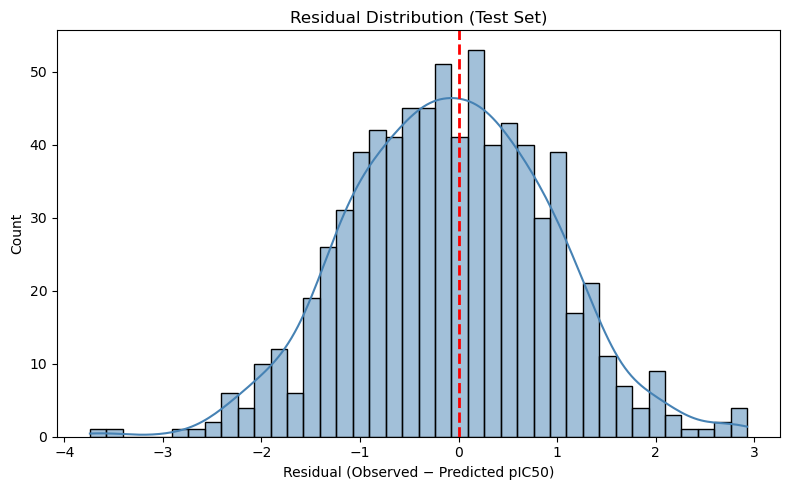

In [48]:
# Residuals (Observed - Predicted)
residuals = y_test - y_test_pred

# Basic statistics
print("Residual mean:", np.mean(residuals))
print("Residual std :", np.std(residuals))

plt.figure(figsize=(8, 5))

sns.histplot(
    residuals,
    bins=40,
    kde=True,
    color="steelblue",
    edgecolor="black"
)

plt.axvline(0, color="red", linestyle="--", linewidth=2)

plt.xlabel("Residual (Observed − Predicted pIC50)")
plt.ylabel("Count")
plt.title("Residual Distribution (Test Set)")

plt.tight_layout()

save_dir = r"C:\Users\nezih\qsar-egfr-regression\reports\figures"
os.makedirs(save_dir, exist_ok=True)

plt.savefig(
    os.path.join(save_dir, "residuals_hist_test.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()


In [ ]:
Residuals are approximately normally distributed and centered around zero, 
indicating that the model does not exhibit strong systematic bias on the test set.

#### **5.4 Feature Importance**

In [49]:
# --- 1) Total feature count (descriptors + fingerprints) ---
n_desc = len(descriptor_cols)          # 6
n_total = rf_final.n_features_in_      # should match X_hybrid columns
n_fp = n_total - n_desc                # 2048 (typically)

print(f"Descriptors: {n_desc}")
print(f"Fingerprints: {n_fp}")
print(f"Total features seen by model: {n_total}")

# --- 2) Get full RF importances (for all features) ---
importances = rf_final.feature_importances_

# --- 3) Slice only the descriptor part (first 6 columns) ---
desc_importances = importances[:n_desc]

# --- 4) Build a clean table ---
fi_desc = (
    pd.DataFrame({
        "Descriptor": descriptor_cols,
        "Importance": desc_importances
    })
    .sort_values("Importance", ascending=False)
    .reset_index(drop=True)
)

fi_desc


Descriptors: 6
Fingerprints: 2048
Total features seen by model: 2054


,Descriptor,Importance
0,MolWt,0.049674
1,MolLogP,0.028482
2,TPSA,0.024720
3,RotatableBonds,0.012914
4,HBA,0.008824
5,HBD,0.006627


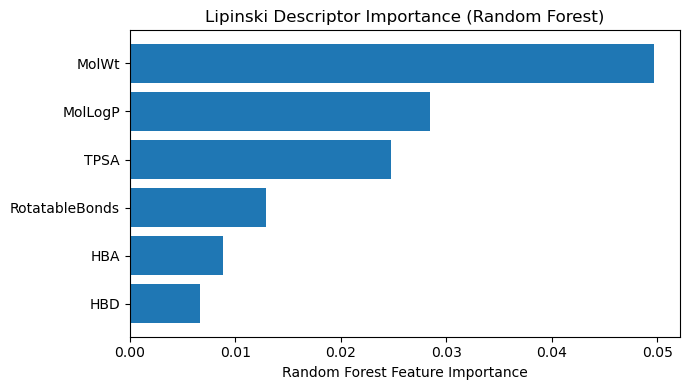

In [51]:
plt.figure(figsize=(7, 4))
plt.barh(fi_desc["Descriptor"][::-1], fi_desc["Importance"][::-1])
plt.xlabel("Random Forest Feature Importance")
plt.title("Lipinski Descriptor Importance (Random Forest)")
plt.tight_layout()

save_dir = r"C:\Users\nezih\qsar-egfr-regression\reports\figures"
os.makedirs(save_dir, exist_ok=True)

plt.savefig(
    os.path.join(save_dir, "rf_descriptor_importance.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()


#### **Lipinski Descriptor Importance (Random Forest)**

Random Forest feature importance analysis indicates that molecular size (MolWt) and lipophilicity (MolLogP) are the most influential physicochemical properties for predicting EGFR inhibitory potency. Polar surface area (TPSA) also contributes substantially, suggesting that an optimal balance between hydrophobicity and polarity is required for effective binding. Flexibility, captured by the number of rotatable bonds, plays a secondary role, while hydrogen bond donors and acceptors have relatively lower importance. Overall, these results are consistent with known structure–activity relationships of kinase inhibitors, where hydrophobic interactions and molecular shape dominate binding affinity.
